In [112]:
# Dependencies

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [113]:
pd.set_option('display.max_columns', 100)
df = pd.read_csv('../data/fake_job_postings.csv')
df.sample(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
8255,8256,Hardware & Software Technician,"US, CA, Encino",IT,NaN,"For over 20 years NAC Marketing Company, LLC d...","Job SummaryAs a member of the team, the Helpde...",Requirements: 2 years professional hardware / ...,Benefits: We believe in the philosophy ‘be hea...,0,1,1,Full-time,Associate,Associate Degree,Consumer Goods,Information Technology,0
8426,8427,Terabytes of ASP.NET,"US, TX, Houston",NaN,NaN,"Based in Houston, Texas, Palladium Consulting ...",Megabytes are a dime a dozen. Most .NET web ap...,.NET experience; not so much Crystal Reports a...,We get better work done for our clients when a...,0,1,1,Full-time,NaN,Bachelor's Degree,Computer Software,NaN,0
9865,9866,Data Analyst,"US, NY, Brooklyn",NaN,NaN,Farmigo is a mission-driven startup with a sim...,Farmigo is looking to hire a brilliant Data An...,"An ability to build strong, collaborative rela...","We love our staff, and we try to show it with ...",0,1,1,Full-time,Associate,NaN,Management Consulting,Data Analyst,0


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [115]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


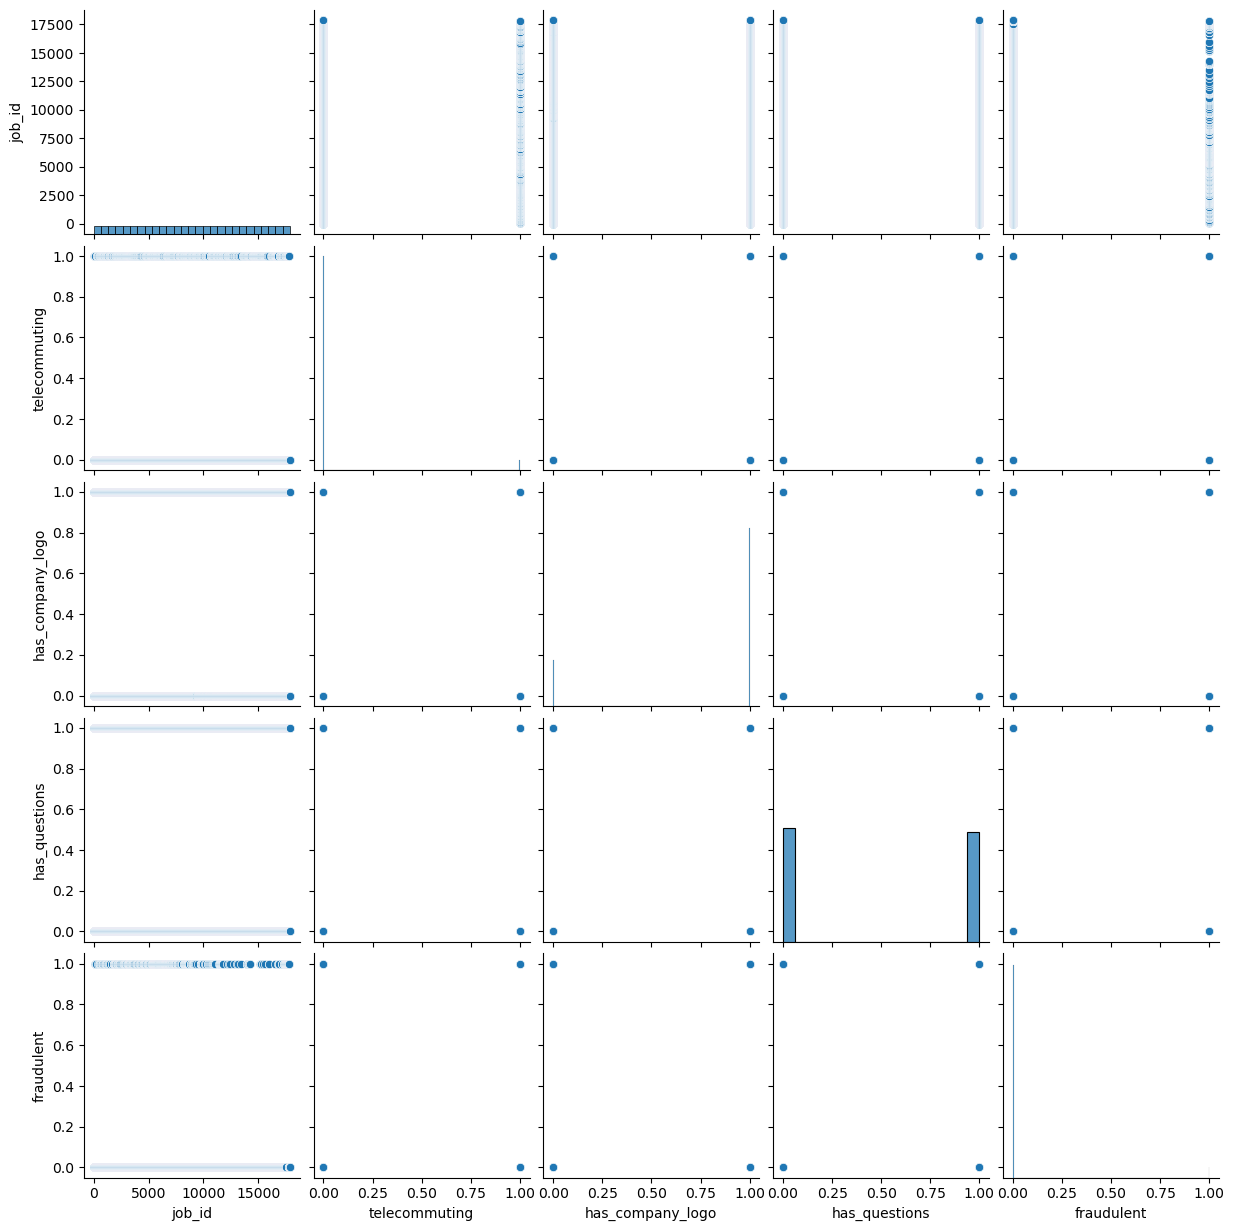

In [116]:
sns.pairplot(df)

In [117]:
df.describe(include='object')

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


In [118]:
df.corr(numeric_only=True)

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
job_id,1.000000,-0.004559,-0.014539,-0.087025,0.079872
telecommuting,-0.004559,1.000000,-0.019836,0.020345,0.034523
has_company_logo,-0.014539,-0.019836,1.000000,0.233932,-0.261971
has_questions,-0.087025,0.020345,0.233932,1.000000,-0.091627
fraudulent,0.079872,0.034523,-0.261971,-0.091627,1.000000


<Axes: >

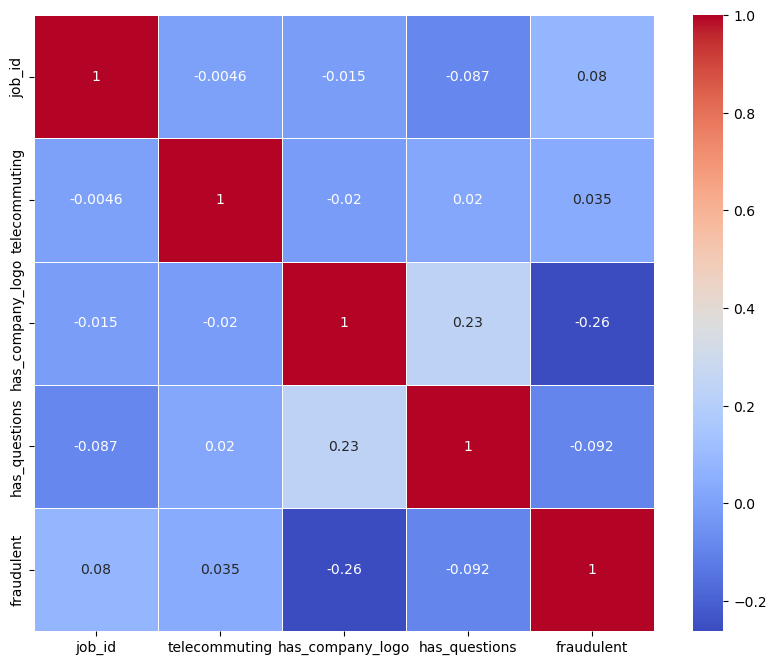

In [119]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)

In [120]:
# get duplicates
df.duplicated().sum()

np.int64(0)

In [121]:
# missing values sum
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [122]:
# handle missing
# only object value types are missing
df.fillna('Missing', inplace=True)

In [123]:
df.location.str.count(",").value_counts()

location
2     17320
0       440
3       104
4         7
5         4
6         2
8         1
15        1
10        1
Name: count, dtype: int64

In [124]:
# Check if first comma is country
df[(df.location.str.count(",") == 10) & (df.location != "Missing")].sample(1)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17571,17572,Work From Home (Easy Money),"US, FL, Orlando,Lake City, Jacksonville,Atlant...",Missing,Missing,DMT Instant Reward. We are Hiring all The Time.,"""Do You Want To Own Your Internet Base Busines...","Computer, Internet and Telephone","Company looking to fill a few CSR places, Job ...",0,1,0,Missing,Missing,Missing,Missing,Missing,1


In [125]:
# handle duplicates
duplicates = df.duplicated()
duplicates[duplicates == True]

Series([], dtype: bool)

In [126]:
# remove guilty outliers
import warnings
warnings.filterwarnings('ignore')

In [127]:
df_subset = df.drop(columns=['job_id'])
# df_melted = df_subset.melt(var_name='Column', value_name='Value')

<Axes: >

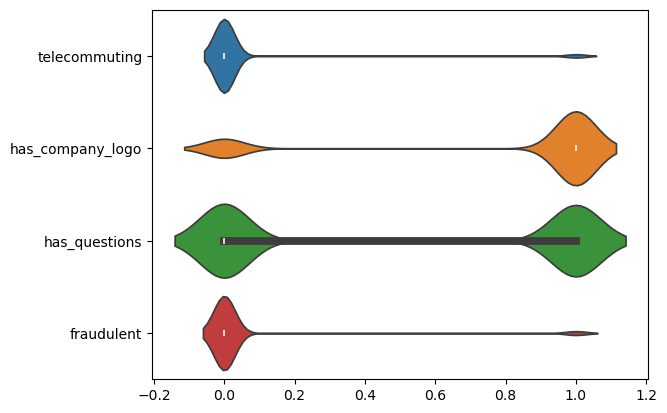

In [128]:
sns.violinplot(data=df_subset, orient='h')

only binary values, and based on understanding of the dataset it is more favoured for real job postings rather than fradulent

Get the unique value for feature engineering and graph to determine relevancy

In [129]:
count = df[['employment_type', 'required_experience', 'required_education', 'industry', 'function']].nunique()
count

employment_type          6
required_experience      8
required_education      14
industry               132
function                38
dtype: int64

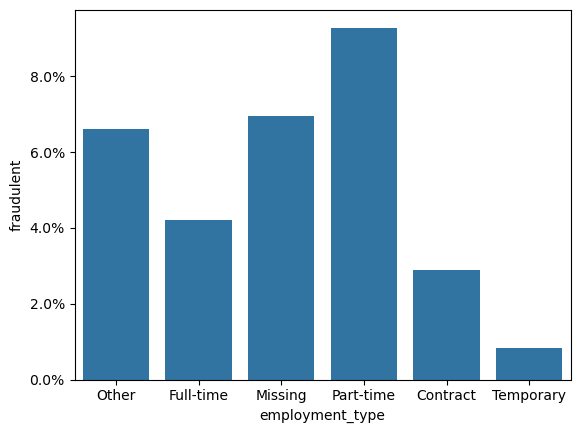

In [130]:
# inspect enployment type, experiences, and education
ax =sns.barplot(data=df,x=df.employment_type, y=df.fraudulent, errorbar=None)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

Potential scam recruiters targeting flexible workers

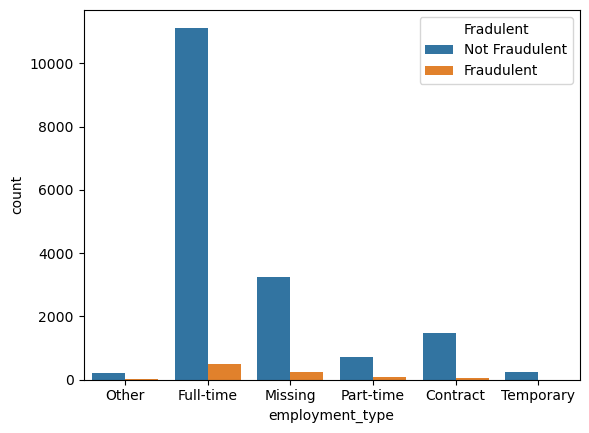

In [131]:
df['Fradulent'] = df.fraudulent.map({0: 'Not Fraudulent', 1: 'Fraudulent'})
sns.countplot(data=df, x='employment_type', hue='Fradulent')
plt.show()

- full time posting are dominate most of the dataset
- fradulent is a minority class, which signifies imbalance
- part-time and missing appear to have higher fraud rates

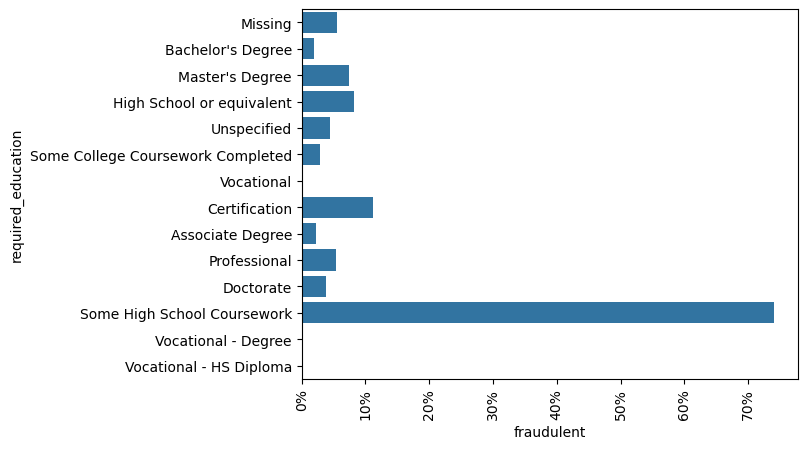

In [132]:
ax =sns.barplot(data=df,y=df.required_education, x=df.fraudulent, errorbar=None)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=90)
plt.show()

In [133]:
df['required_education'].value_counts()

required_education
Missing                              8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

Some college coursework completed has small amount of values in the dataset but are highly likely to be fradualent. Ceritification is also not highly present as a type but contains the second most amount of fradulent cases.

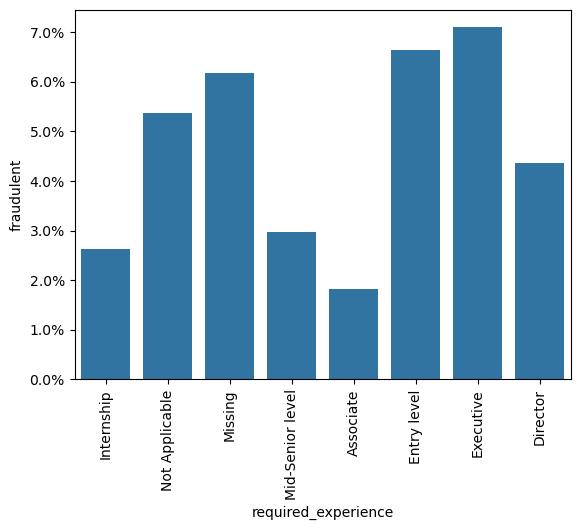

In [134]:
ax =sns.barplot(data=df,x=df.required_experience, y=df.fraudulent, errorbar=None)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=90)
plt.show()

In [135]:
df['required_experience'].value_counts()

required_experience
Missing             7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

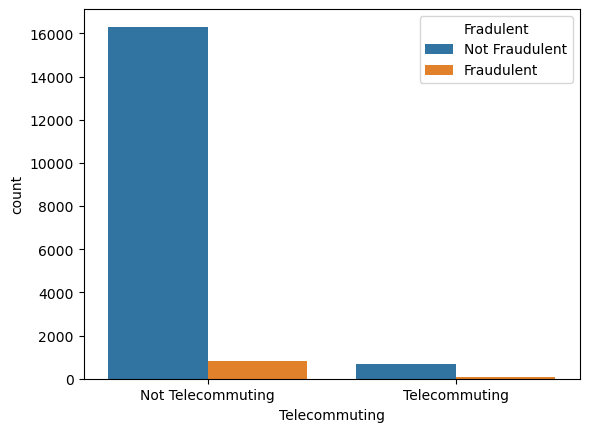

In [136]:
df['Fradulent'] = df.fraudulent.map({0: 'Not Fraudulent', 1: 'Fraudulent'})
df['Telecommuting'] = df.telecommuting.map({0: 'Not Telecommuting', 1: 'Telecommuting'})
sns.countplot(data=df, x='Telecommuting', hue='Fradulent')
plt.show()

In [146]:
df['country'] = df.location.str.split(',').str[0].replace('', 'Missing').fillna('Missing')
df['country'].value_counts().head(10)

country
US         10656
GB          2384
GR           940
CA           457
DE           383
Missing      346
NZ           333
IN           276
AU           214
PH           132
Name: count, dtype: int64

In [138]:
count = (df['country'] == 'Missing').sum()
count

np.int64(346)

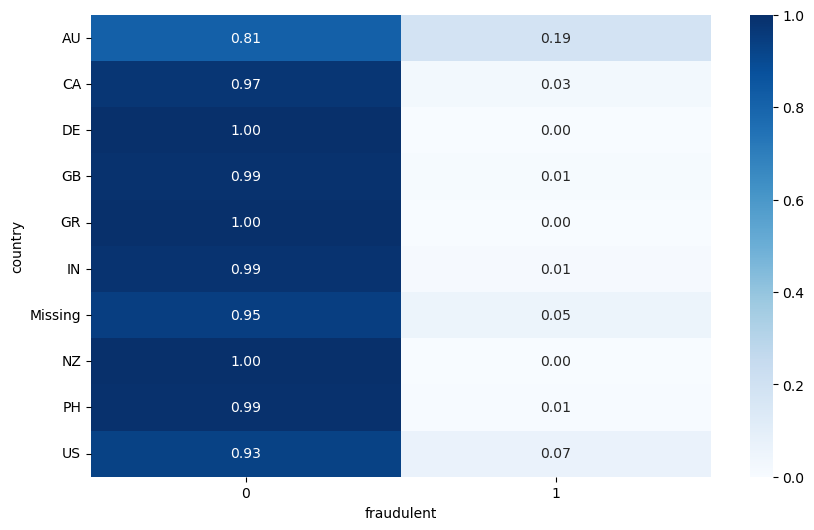

In [143]:
top_countries = df['country'].value_counts().head(10).index
data = df[df['country'].isin(top_countries)]
heatmap_data = pd.crosstab(data['country'], data['fraudulent'], normalize='index')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues')
plt.yticks(rotation=0)
plt.show()


In [147]:
top_countries = [
    'US',
    'GB',
    'GR',
    'CA',
    'DE',
    'NZ',
    'IN',
    'AU',
    'PH',
    'Missing'
]

df['country'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

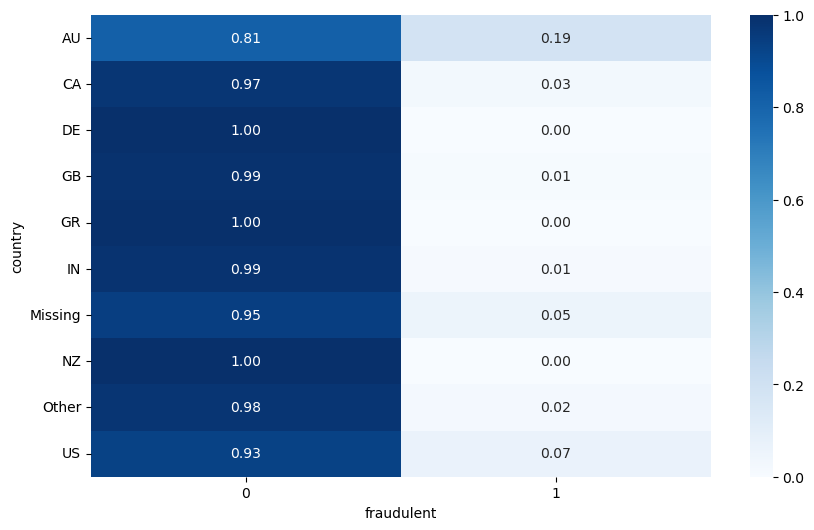

In [149]:
top_countries = df['country'].value_counts().head(10).index
data = df[df['country'].isin(top_countries)]
heatmap_data = pd.crosstab(data['country'], data['fraudulent'], normalize='index')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues')
plt.yticks(rotation=0)
plt.show()

In [148]:
df['country'].value_counts()

country
US         10656
GB          2384
Other       1759
GR           940
CA           457
DE           383
Missing      346
NZ           333
IN           276
AU           214
PH           132
Name: count, dtype: int64

Not including countries due to the large imbalance of values, and classifying the lower country values into a new category can cause issues. 
With the idea of the web application in mind it is not less feasible

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17880 non-null  object
 3   department           17880 non-null  object
 4   salary_range         17880 non-null  object
 5   company_profile      17880 non-null  object
 6   description          17880 non-null  object
 7   requirements         17880 non-null  object
 8   benefits             17880 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      17880 non-null  object
 13  required_experience  17880 non-null  object
 14  required_education   17880 non-null  object
 15  industry             17880 non-null  object
 16  func

In [152]:
df.to_csv('../data/fake_job_postings_cleaned.csv', index=None)